# Data Understanding and Cleaning

In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv('apnaklub_data_2.csv')

# Convert order_date to datetime format
data['order_date'] = pd.to_datetime(data['order_date'])

# Check for missing values
missing_values = data.isnull().sum()

# Drop or fill missing values (based on business rules)
data.fillna(method='ffill', inplace=True)

C:\Users\srini\AppData\Local\Temp\ipykernel_26580\2334520153.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


# Customer Behavior Analysis

In [2]:
customer_behavior = data.groupby('user_id').agg({
    'order_id': 'nunique',  # Number of unique orders
    'quantity': 'sum',      # Total quantity ordered
    'placed_gmv': 'sum'     # Total value of orders placed
}).reset_index()

customer_behavior.columns = ['user_id', 'total_orders', 'total_quantity', 'total_gmv']

# Segment customers into high, medium, and low spenders based on GMV
customer_behavior['segment'] = pd.qcut(customer_behavior['total_gmv'], q=3, labels=['Low', 'Medium', 'High'])


In [3]:
repeat_customers = customer_behavior[customer_behavior['total_orders'] > 1]
repeat_rate = len(repeat_customers) / len(customer_behavior) * 100

# Sales Trends Analysis

In [4]:
sales_trends = data.groupby(data['order_date'].dt.to_period('M')).agg({
    'placed_gmv': 'sum',
    'order_id': 'nunique'
}).reset_index()

sales_trends.columns = ['order_month', 'total_gmv', 'total_orders']

In [5]:
data['order_week'] = data['order_date'].dt.to_period('W')
order_frequency = data.groupby('user_id')['order_id'].nunique().mean()

# SKU Performance Analysis

In [6]:
sku_performance = data.groupby('sku_id').agg({
    'placed_gmv': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

sku_performance.columns = ['sku_id', 'total_gmv', 'total_quantity', 'total_orders']

# Top 10 performing SKUs
top_skus = sku_performance.sort_values(by='total_gmv', ascending=False).head(10)

# Bottom 10 performing SKUs
bottom_skus = sku_performance.sort_values(by='total_gmv', ascending=True).head(10)

In [7]:
sku_demand = sku_performance[['sku_id', 'total_quantity']].sort_values(by='total_quantity', ascending=False)

# Warehouse Efficiency

In [8]:
warehouse_performance = data.groupby('warehouse_name').agg({
    'placed_gmv': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

warehouse_performance.columns = ['warehouse_name', 'total_gmv', 'total_quantity', 'total_orders']

# Visualization

C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


TypeError: Invalid object type at position 0

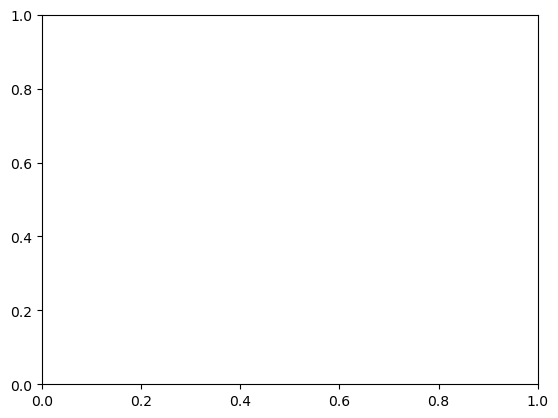

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot sales trends over time
sns.lineplot(x='order_month', y='total_gmv', data=sales_trends)
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

# Plot top-performing SKUs
sns.barplot(x='sku_id', y='total_gmv', data=top_skus)
plt.title('Top 10 Performing SKUs by GMV')
plt.xticks(rotation=45)
plt.show()
